In [2]:
from glob import glob

In [24]:
glob("./OptimizeIterationsResults/OptunaDDPGExp0001/*/metadata.pkl")

['./OptimizeIterationsResults/OptunaDDPGExp0001\\119_2024-10-21_13-39-39\\metadata.pkl',
 './OptimizeIterationsResults/OptunaDDPGExp0001\\11_2024-10-20_23-43-05\\metadata.pkl',
 './OptimizeIterationsResults/OptunaDDPGExp0001\\120_2024-10-21_14-45-03\\metadata.pkl',
 './OptimizeIterationsResults/OptunaDDPGExp0001\\127_2024-10-21_07-11-03\\metadata.pkl',
 './OptimizeIterationsResults/OptunaDDPGExp0001\\136_2024-10-20_03-01-49\\metadata.pkl',
 './OptimizeIterationsResults/OptunaDDPGExp0001\\142_2024-10-21_13-17-01\\metadata.pkl',
 './OptimizeIterationsResults/OptunaDDPGExp0001\\156_2024-10-21_05-45-21\\metadata.pkl',
 './OptimizeIterationsResults/OptunaDDPGExp0001\\165_2024-10-20_05-12-59\\metadata.pkl',
 './OptimizeIterationsResults/OptunaDDPGExp0001\\166_2024-10-21_03-37-28\\metadata.pkl',
 './OptimizeIterationsResults/OptunaDDPGExp0001\\183_2024-10-20_10-52-15\\metadata.pkl',
 './OptimizeIterationsResults/OptunaDDPGExp0001\\203_2024-10-20_06-58-42\\metadata.pkl',
 './OptimizeIterations

In [6]:
glob('OptimizeIterationsResults/*')

['OptimizeIterationsResults\\test.txt']

In [5]:
import pandas as pd

In [9]:
df = pd.read_csv("./OptimizeIterationsResults/OptunaDDPGExp0001/trialsData.csv", index_col=0)

In [10]:
df 

,number,value,datetime_start,datetime_complete,duration,params_batch_size,params_gamma,params_learning_rate,params_tau,state
0,0,-2.449195e+07,2024-10-20 01:12:04.063127,2024-10-20 01:34:04.734385,0 days 00:22:00.671258,278,0.919363,0.000030,0.016816,COMPLETE
1,1,-1.114091e+07,2024-10-20 01:34:04.734385,2024-10-20 01:55:57.769901,0 days 00:21:53.035516,294,0.911956,0.000100,0.073597,COMPLETE
2,2,-2.137553e+07,2024-10-20 01:55:57.769901,2024-10-20 02:17:37.736806,0 days 00:21:39.966905,215,0.979392,0.000046,0.056864,COMPLETE
3,3,-1.175348e+07,2024-10-20 02:17:37.737804,2024-10-20 02:39:51.505128,0 days 00:22:13.767324,317,0.998211,0.000022,0.043426,COMPLETE
4,4,-5.672319e+06,2024-10-20 02:39:51.505927,2024-10-20 03:01:50.444953,0 days 00:21:58.939026,269,0.929843,0.000022,0.029363,COMPLETE
...,...,...,...,...,...,...,...,...,...,...
95,95,-4.687975e+06,2024-10-21 12:55:38.648651,2024-10-21 13:17:02.563151,0 days 00:21:23.914500,82,0.960989,0.000875,0.095610,COMPLETE
96,96,8.835399e+05,2024-10-21 13:17:02.564152,2024-10-21 13:39:40.742881,0 days 00:22:38.178729,263,0.951993,0.000675,0.091086,COMPLETE
97,97,-1.980335e+07,2024-10-21 13:39:40.743881,2024-10-21 14:01:49.815927,0 days 00:22:09.072046,232,0.964072,0.000714,0.093542,COMPLETE
98,98,2.025058e+06,2024-10-21 14:01:49.816920,2024-10-21 14:23:13.097809,0 days 00:21:23.280889,49,0.959433,0.000590,0.081696,COMPLETE


In [14]:
#convert the value column to type float
df['value'] = df['value'].astype(float)

In [23]:
df.iloc[df['value'].idxmax()]

number                                          19
value                              23479946.794118
datetime_start          2024-10-20 08:03:17.768128
datetime_complete       2024-10-20 08:24:12.573282
duration                    0 days 00:20:54.805154
params_batch_size                               75
params_gamma                              0.961435
params_learning_rate                      0.000515
params_tau                                0.099992
state                                     COMPLETE
valueToPlot                        23479946.794118
Name: 19, dtype: object

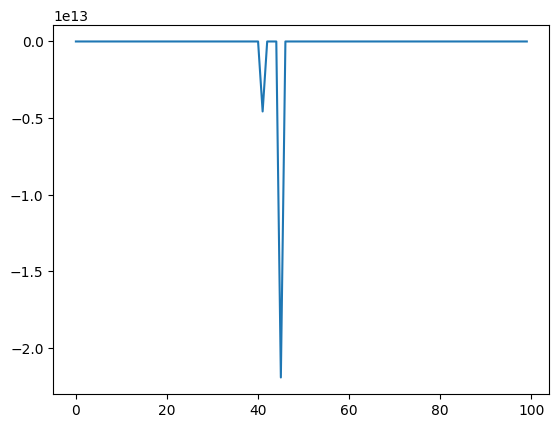

In [15]:
#plot the values of the trials respect the number column
import matplotlib.pyplot as plt

plt.plot(df.number, df.value)

In [19]:
# Cap the minimum value to 0
df['valueToPlot'] = df['value'].apply(lambda x: max(x, 0))

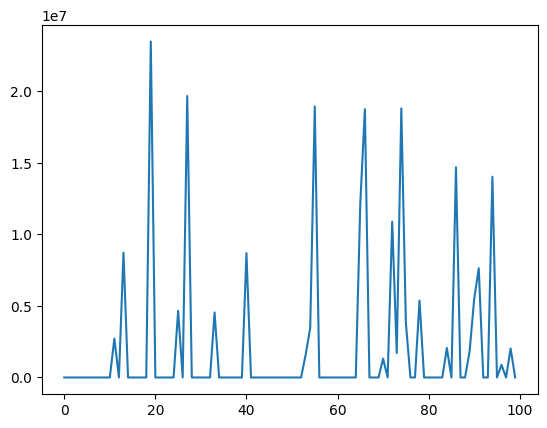

In [22]:
#plot in scatter
plt.plot(df.number, df.valueToPlot)
plt.show()


In [33]:
#Run across the list of files and get the folder with the hPrameters that have the best value
fileList = glob("./OptimizeIterationsResults/OptunaDDPGExp0001/*/metadata.pkl")

bestvalueHPs = {"params_batch_size" :75 ,
"params_gamma" : 0.961435 ,
"params_learning_rate" : 0.000515 ,
"params_tau" : 0.099992}

for file in fileList:
    df = pd.read_pickle(file)
    #print(df['HP_PARAMS'])
    if df['HP_PARAMS']['batch_size'] == bestvalueHPs['params_batch_size'] :
        print(str(file))
        bestModeldir = file
        break

./OptimizeIterationsResults/OptunaDDPGExp0001\582_2024-10-20_08-24-11\metadata.pkl


In [34]:
bestModeldir

'./OptimizeIterationsResults/OptunaDDPGExp0001\\582_2024-10-20_08-24-11\\metadata.pkl'

False